# Explore RSE anomaly scores

In [1]:
import os
# Set environment variables to disable multithreading
# as users will probably want to set the number of cores
# to the max of their computer.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

import seaborn as sns

from anomaly.constants import GALAXY_LINES
from anomaly.utils import specobjid_to_idx
from anomaly.utils import VelocityFilter
from anomaly.utils import AnomalyOverlapAnalyzer
from autoencoders.ae import AutoEncoder

from sdss.metadata import MetaData

meta = MetaData()

# Constants

In [20]:
se_cols = [
    'mse',
    'mse_filter_250',
    # 'mse_filter_300',
    'mse_97',
    # 'mse_95',
    'mse_filter_250_97',
    # 'mse_filter_250_95',
    # 'mse_filter_300_97', 'mse_filter_300_95'
]

se_rank_cols = [
    f"rank_{col}" for col in se_cols
]

# ----------------------------------------------
rse_cols = [
    f"{col}_rel" for col in se_cols
]

rse_rank_cols = [
    f"rank_{col}_rel" for col in se_cols
]
# ----------------------------------------------
se_family = [
    'mse',
    'mse_97',
    # 'mse_95',
    'mse_filter_250',
    # 'mse_filter_300',
    'mse_filter_250_97',
    # 'mse_filter_250_95',
    # 'mse_filter_300_97', 'mse_filter_300_95'
]

rse_family = [
    f'{col}_rel' for col in se_family
]

# Custom functions

## Squared residual

In [4]:
def squared_residual(spec, spec_rec):

    flux_diff = np.abs(spec - spec_rec)
    
    return flux_diff**2

## RSE-iduals

## fine grained

In [5]:
def rse_residual(spec, spec_rec):

    flux_diff_sq = np.abs(spec - spec_rec)**2
    flux_factor = flux_diff_sq / np.abs(spec + 0.001)
    
    return flux_factor

## RSE fig

In [6]:
def fig_RSEidual(
    wave, wave_ticks, wave_lims,
    spec, rec_spec,
    flux_ticks, flux_lims,
    residual,
    res_ticks, res_lims,
    alpha = 0.5,
    figsize=(10, 7)
):

    fig, axs = plt.subplots(
        2, 1,
        sharex=True,
        figsize=figsize
    )
    # ----------------------------------------------------
    axs[0].plot(
        wave, spec,
        color="black", label="Original"
    )
    axs[0].plot(
        wave, rec_spec,
        color="red", alpha=alpha, label="Reconstruction"
    )

    if flux_ticks is False:
        pass
    else:
        axs[0].set_yticks(flux_ticks)
    
    if flux_lims is False:
        pass
    else:
        f_min, f_max = flux_lims
        axs[0].set_ylim(f_min, f_max)
    # ----------------------------------------------------
    # Residulas
    axs[1].plot(
        wave, residual,
        color="black", label="Residuals"
    )

    if res_ticks is False:
        pass
    else:
        axs[1].set_yticks(res_ticks)

    if res_lims is False:
        pass
    else:
        res_min, res_max = res_lims 
        axs[1].set_ylim(res_min, res_max)

    # ----------------------------------------------------
    # labels
    axs[0].legend(
        loc='upper left',
        frameon=False,
        ncol=2
    )
    axs[1].legend(loc='upper left', frameon=False)

    # ----------------------------------------------------

    # wavelengt setup
    if wave_lims is False:
        pass
    else: 
        w_min, w_max = wave_lims
        axs[1].set_xlim(w_min, w_max)

    if wave_ticks is False:
        pass
    else:
        axs[1].set_xticks(wave_ticks)

    # set minor ticks on
    for ax in axs.flatten(): ax.minorticks_on()
    # axe labels
    # x
    axs[1].set_xlabel(r"$\lambda$ [nm]")
    # y
    axs[0].set_ylabel("Flux")
    axs[1].set_ylabel("RES-iduals")

    return fig, axs


## RSE vs SE Fig

In [7]:
def rse_se_fig(
    spec, rec_spec, 
    wave_nm, 
    rseidual, squared_res,
    rse_rank, se_rank, 
    figsize=(20, 7), alpha=0.5
):

    fig, axs = plt.subplots(
        2, 2,
        sharex=True,
        figsize=figsize
    )
    # ----------------------------------------------------
    # 
    axs[0, 0].plot(
        wave_nm, spec,
        color="black", label="Original"
    )

    axs[0, 0].plot(
        wave_nm, rec_spec,
        alpha=alpha,
        color="red", label="Reconstruction"
    )

    # ----------------------------------------------------
    axs[0, 1].plot(
        wave_nm, spec,
        color="black", label="Original"
    )
    axs[0, 1].plot(
        wave_nm, rec_spec,
        color="red", alpha=alpha, label="Reconstruction"
    )

    # ----------------------------------------------------
    # Residulas
    # RSE
    axs[1, 0].plot(
        wave_nm, rseidual,
        color="black",
        # label="Residuals"
    )

    axs[1, 0].text(
        0.95, 0.95,
        f"SE Rank: {rse_rank:.0f}",
        horizontalalignment="right", verticalalignment="center",
        transform=axs[1, 0].transAxes,
        fontsize=12
    )

    # SE
    axs[1, 1].plot(
        wave_nm, squared_res,
        color="black",
        # label="Residuals"
    )

    axs[1, 1].text(
        0.95, 0.95,
        f"RSE Rank: {se_rank:.0f}",
        horizontalalignment="right", verticalalignment="center",
        transform=axs[1, 1].transAxes,
        fontsize=12
    )
    # ----------------------------------------------------
    # labels
    axs[0, 0].legend(
        loc='upper left',
        frameon=False,
        # fontsize=10,
        ncol=2
    )
    axs[0, 1].legend(
        loc='upper left',
        frameon=False,
        # fontsize=10,
        ncol=2
    )
    # ----------------------------------------------------
    # wavelengt setup
    axs[1, 0].set_xlim(350, 770)
    axs[1, 1].set_xlim(350, 770)
    wave_ticks = list(np.arange(350, 751, 50))
    axs[1, 0].set_xticks(wave_ticks)
    axs[1, 1].set_xticks(wave_ticks)
    # set minor ticks on
    for ax in axs.flatten(): ax.minorticks_on()

    # ax labels
    axs[1, 0].set_xlabel(r"$\lambda$ [nm]")
    axs[1, 1].set_xlabel(r"$\lambda$ [nm]")
    axs[0, 0].set_ylabel("Flux")
    axs[1, 0].set_ylabel(r"SE($\lambda$)")
    axs[1, 1].set_ylabel(r"RSE($\lambda$)")

    return fig, axs

# Config

## Directories

In [8]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
bin_id = 'bin_03'
#
ch_4_dir = f"{thesis_dir}/chapters/04_figures"
os.makedirs(f"{ch_4_dir}/{bin_id}", exist_ok=True)

## Data

In [9]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave*0.1
n_wave = wave.shape

spectra = np.load(
    f"{spectra_dir}/spectra_imputed.npy",
    mmap_mode="r"
)

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(
    f"{spectra_dir}/ids_imputing.npy",
    mmap_mode='r'
)


In [10]:
emission_lines = list(GALAXY_LINES.keys())

velocity_fil_fn = VelocityFilter(
    wave=wave, velocity_filter=250,
    lines=emission_lines
)

vel_mask = velocity_fil_fn.get_velocity_filter_mask()

## Model

In [11]:
ae_model = AutoEncoder(
    reload=True,
    reload_from=f"{models_dir}/{bin_id}/winner",
)

## Scores

In [12]:
score_df = pd.read_csv(
    f"{scores_dir}/{bin_id}/scores_{bin_id}.csv.gz",
    index_col='specobjid'
)

rank = np.arange(score_df.shape[0]) + 1
score_rank_df = score_df.copy()
# score_rank_df
for col in score_df.columns:

    index_sorted = score_df.sort_values(
        by=col, ascending=False
    ).index

    score_rank_df.loc[index_sorted, f'rank_{col}'] = rank
    score_rank_df[f'rank_{col}'].astype(int)

In [13]:
score_rank_df[['rank_mse_rel', 'mse_rel']].sort_values(by='mse_rel', ascending=False).head(5)

,rank_mse_rel,mse_rel
specobjid,,
305239577747023872,1.0,24.499810
2830625680629196800,2.0,24.441423
2830685054257096704,3.0,24.168451
734111514142730240,4.0,23.134280
3240467000396376064,5.0,22.655893


# RSE Vs SE

In [14]:
rse_rank_candidates = [
    7, 11, 15, 20, 21, 27, 47,
    72, # artifact rank 1 in mse
    856, 911
]
# # show rank_mse_rel rank_mse for rse_rank_candidates
# for candidate in rse_rank_candidates:
#     # print(f"RSE Rank: {candidate}")
#     mask = score_rank_df['rank_mse_rel'] == candidate
#     print(score_rank_df[mask][['rank_mse_rel', 'rank_mse']])

## Artifact top 1 in SE

rank_mse                          1.0
rank_mse_rel                     72.0
rank_mse_filter_250_rel          24.0
rank_mse_97_rel               56002.0
rank_mse_filter_250_97_rel    36122.0
Name: 407596690535639040, dtype: float64

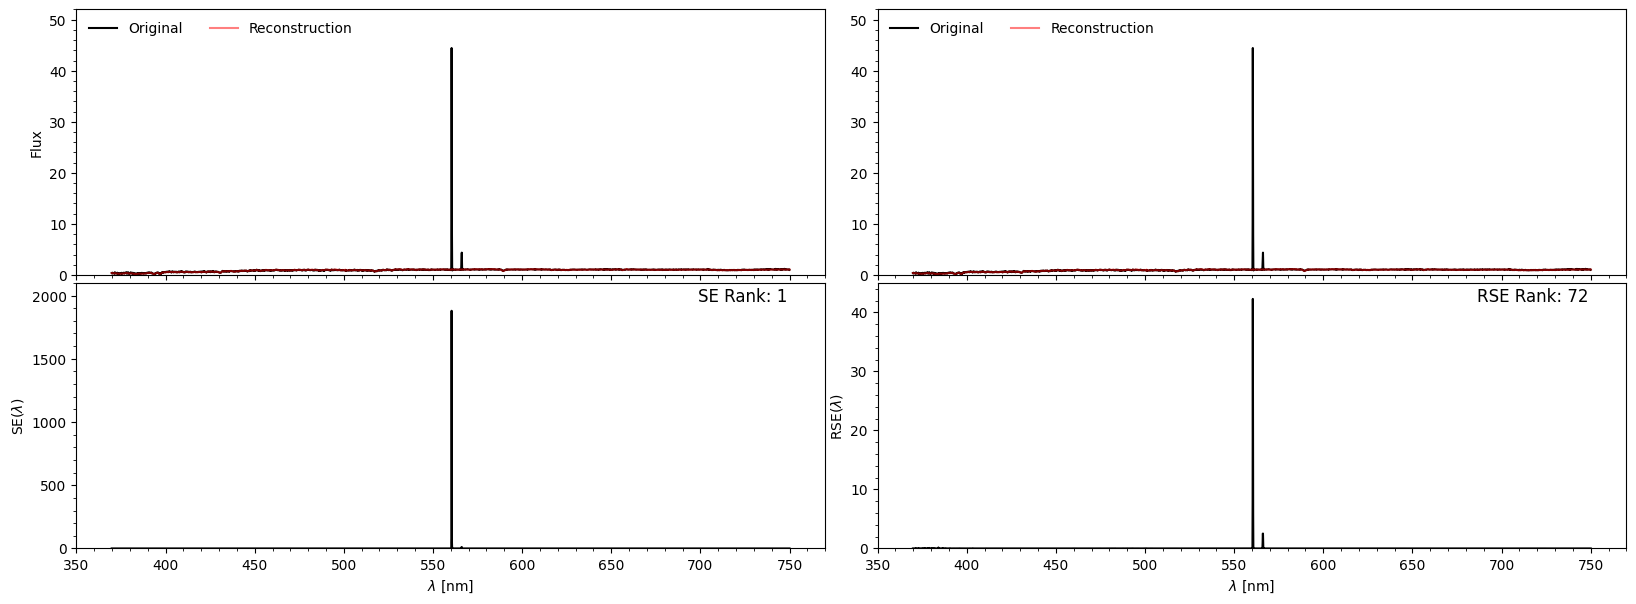

In [24]:
rse_rank = 72
mask = score_rank_df.rank_mse_rel == rse_rank
specid = score_rank_df.loc[mask].index.values[0]
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
RSEidual = rse_residual(spec, rec_spec)
squared_res = squared_residual(spec, rec_spec)
# 
rse_rank = score_rank_df.loc[specid, 'rank_mse_rel']
se_rank = score_rank_df.loc[specid, 'rank_mse']
# -------------------------------------------------------
fig, axs = rse_se_fig(
    spec, rec_spec, wave_nm,
    squared_res, RSEidual,
    se_rank, rse_rank,
    alpha=0.5
)
# --------------------------------------------------------
# Flux
flux_ticks = [0, 10, 20, 30, 40, 50]
flux_min, flux_max = (0, 52)
axs[0, 0].set_yticks(flux_ticks)
axs[0, 0].set_ylim(flux_min, flux_max)
axs[0, 1].set_yticks(flux_ticks)
axs[0, 1].set_ylim(flux_min, flux_max)
# --------------------------------------------------------
# Residuals
res_ticks = [0, 500, 1000, 1500, 2000]
res_min, res_max = (0, 2100)
axs[1, 0].set_ylim(res_min, res_max)
axs[1, 0].set_yticks(res_ticks)
# 
res_ticks = [0, 10, 20, 30, 40]
res_min, res_max = (0, 45)
axs[1, 1].set_ylim(res_min, res_max)
axs[1, 1].set_yticks(res_ticks)
# adjust vertical space
plt.subplots_adjust(
    hspace=0.03, 
    wspace=0.07
)
# -------------------------------------------------------
fig.savefig(
    f"{ch_4_dir}/{bin_id}/rse/rse_rank_{rse_rank:.0f}_vs_se.pdf",
    bbox_inches='tight'
)
score_rank_df.loc[specid, ['rank_mse'] + rse_rank_cols].T

## blue slope with dip in red end

rank_mse                      162.0
rank_mse_rel                   21.0
rank_mse_filter_250_rel         4.0
rank_mse_97_rel                50.0
rank_mse_filter_250_97_rel     44.0
Name: 1959139281477855232, dtype: float64

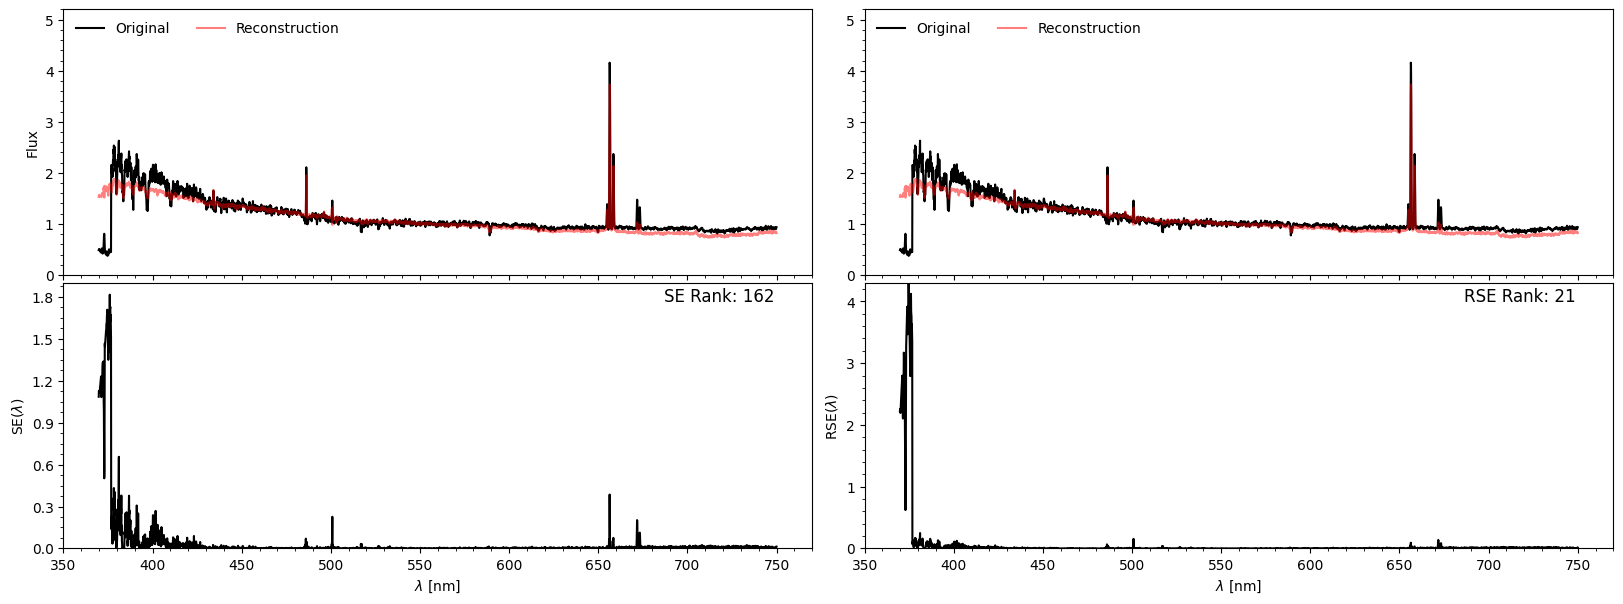

In [25]:
rse_rank = 21
mask = score_rank_df.rank_mse_rel == rse_rank
specid = score_rank_df.loc[mask].index.values[0]
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
RSEidual = rse_residual(spec, rec_spec)
squared_res = squared_residual(spec, rec_spec)
# 
rse_rank = score_rank_df.loc[specid, 'rank_mse_rel']
se_rank = score_rank_df.loc[specid, 'rank_mse']
# -------------------------------------------------------
fig, axs = rse_se_fig(
    spec, rec_spec, wave_nm,
    squared_res, RSEidual,
    se_rank, rse_rank,
    alpha=0.5
)
# --------------------------------------------------------
# Flux
flux_ticks = [0, 1, 2, 3, 4, 5]
flux_min, flux_max = (0, 5.2)
axs[0, 0].set_yticks(flux_ticks)
axs[0, 0].set_ylim(flux_min, flux_max)
axs[0, 1].set_yticks(flux_ticks)
axs[0, 1].set_ylim(flux_min, flux_max)
# --------------------------------------------------------
# Residuals
res_ticks = [0, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8]
res_min, res_max = (0, 1.9)
axs[1, 0].set_ylim(res_min, res_max)
axs[1, 0].set_yticks(res_ticks)
# 
res_ticks = [0, 1, 2, 3, 4]
res_min, res_max = (0, 4.3)
axs[1, 1].set_ylim(res_min, res_max)
axs[1, 1].set_yticks(res_ticks)
# adjust vertical space
plt.subplots_adjust(
    hspace=0.03, 
    wspace=0.07
)
# -------------------------------------------------------
fig.savefig(
    f"{ch_4_dir}/{bin_id}/rse/rse_rank_{rse_rank:.0f}_vs_se.pdf",
    bbox_inches='tight'
)
score_rank_df.loc[specid, ['rank_mse'] + rse_rank_cols].T

## Top anomaly in both

rank_mse                      5.0
rank_mse_rel                  7.0
rank_mse_filter_250_rel       3.0
rank_mse_97_rel               4.0
rank_mse_filter_250_97_rel    4.0
Name: 2930814289679771648, dtype: float64

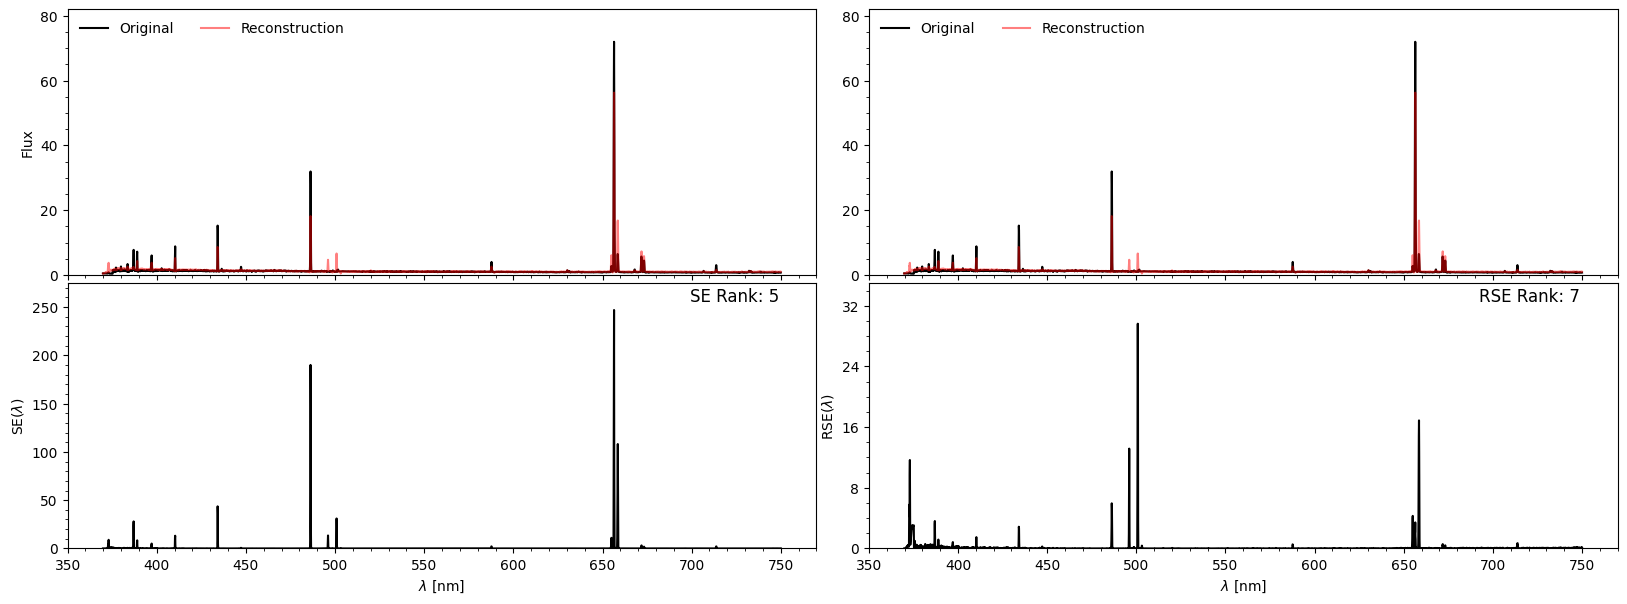

In [27]:
rse_rank = 7
mask = score_rank_df.rank_mse_rel == rse_rank
specid = score_rank_df.loc[mask].index.values[0]
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
RSEidual = rse_residual(spec, rec_spec)
squared_res = squared_residual(spec, rec_spec)
# 
rse_rank = score_rank_df.loc[specid, 'rank_mse_rel']
se_rank = score_rank_df.loc[specid, 'rank_mse']
# -------------------------------------------------------
fig, axs = rse_se_fig(
    spec, rec_spec, wave_nm,
    squared_res, RSEidual,
    se_rank, rse_rank,
    alpha=0.5
)
# --------------------------------------------------------
# Flux
flux_ticks = [0, 20, 40, 60, 80]
flux_min, flux_max = (0, 82)
axs[0, 0].set_yticks(flux_ticks)
axs[0, 0].set_ylim(flux_min, flux_max)
axs[0, 1].set_yticks(flux_ticks)
axs[0, 1].set_ylim(flux_min, flux_max)
# --------------------------------------------------------
# Residuals
res_ticks = [0, 50, 100, 150, 200, 250]
res_min, res_max = (0, 275)
axs[1, 0].set_ylim(res_min, res_max)
axs[1, 0].set_yticks(res_ticks)
# 
res_ticks = [0, 8, 16, 24, 32]
res_min, res_max = (0, 35)
axs[1, 1].set_ylim(res_min, res_max)
axs[1, 1].set_yticks(res_ticks)
# adjust vertical space
plt.subplots_adjust(
    hspace=0.03, 
    wspace=0.07
)
# -------------------------------------------------------
fig.savefig(
    f"{ch_4_dir}/{bin_id}/rse/rse_rank_{rse_rank:.0f}_vs_se.pdf",
    bbox_inches='tight'
)
score_rank_df.loc[specid, ['rank_mse'] + rse_rank_cols].T

## Another candidates

rank_mse                         425.0
rank_mse_rel                     911.0
rank_mse_filter_250_rel         9131.0
rank_mse_97_rel               145157.0
rank_mse_filter_250_97_rel    161481.0
Name: 1882639117586556928, dtype: float64

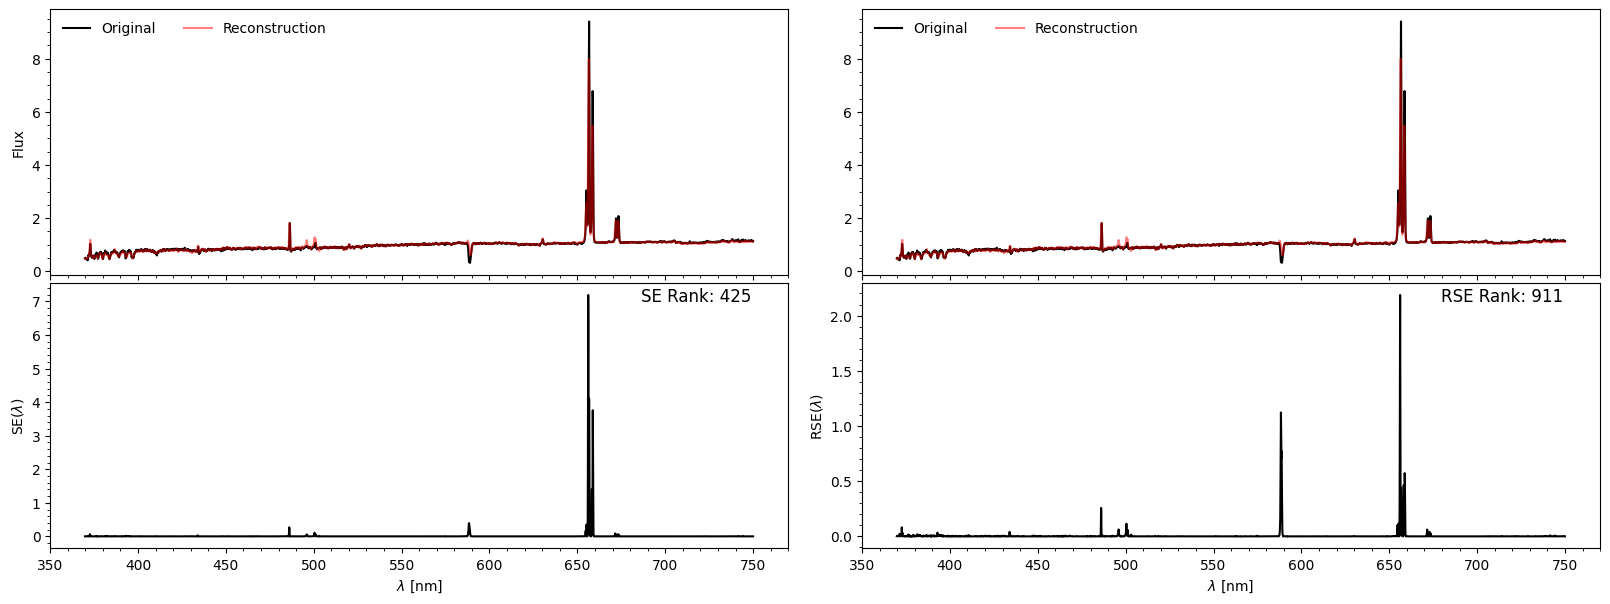

In [31]:
rse_rank = 911
mask = score_rank_df.rank_mse_rel == rse_rank
specid = score_rank_df.loc[mask].index.values[0]
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
RSEidual = rse_residual(spec, rec_spec)
squared_res = squared_residual(spec, rec_spec)
# 
rse_rank = score_rank_df.loc[specid, 'rank_mse_rel']
se_rank = score_rank_df.loc[specid, 'rank_mse']
# -------------------------------------------------------
fig, axs = rse_se_fig(
    spec, rec_spec, wave_nm,
    squared_res, RSEidual,
    se_rank, rse_rank,
    alpha=0.5
)
# adjust vertical space
plt.subplots_adjust(
    hspace=0.03, 
    wspace=0.1
)
# -------------------------------------------------------
score_rank_df.loc[specid, ['rank_mse'] + rse_rank_cols].T


rank_mse                      37.0
rank_mse_rel                  11.0
rank_mse_filter_250_rel        1.0
rank_mse_97_rel                1.0
rank_mse_filter_250_97_rel     1.0
Name: 1919783100783552512, dtype: float64

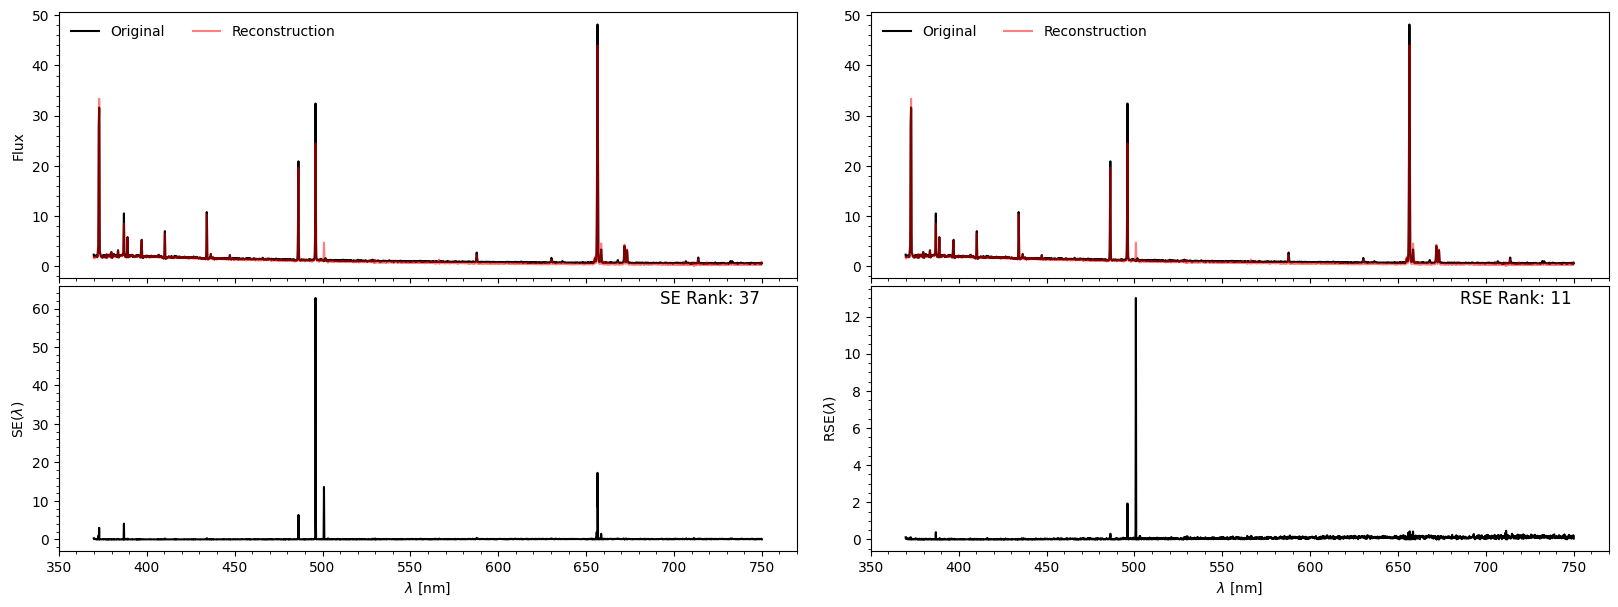

In [ ]:
mask = score_rank_df.rank_mse_rel == 11
specid = score_rank_df.loc[mask].index.values[0]
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
RSEidual = rse_residual(spec, rec_spec)
squared_res = squared_residual(spec, rec_spec)
# 
rse_rank = score_rank_df.loc[specid, 'rank_mse_rel']
se_rank = score_rank_df.loc[specid, 'rank_mse']
# -------------------------------------------------------
fig, axs = rse_se_fig(
    spec, rec_spec, wave_nm,
    squared_res, RSEidual,
    se_rank, rse_rank,
    alpha=0.5
)
# adjust vertical space
plt.subplots_adjust(
    hspace=0.03, 
    wspace=0.1
)
# -------------------------------------------------------
score_rank_df.loc[specid, ['rank_mse'] + rse_rank_cols].T

rank_mse                      42.0
rank_mse_rel                  20.0
rank_mse_filter_250_rel        9.0
rank_mse_97_rel                3.0
rank_mse_filter_250_97_rel     3.0
Name: 1071977423131666432, dtype: float64

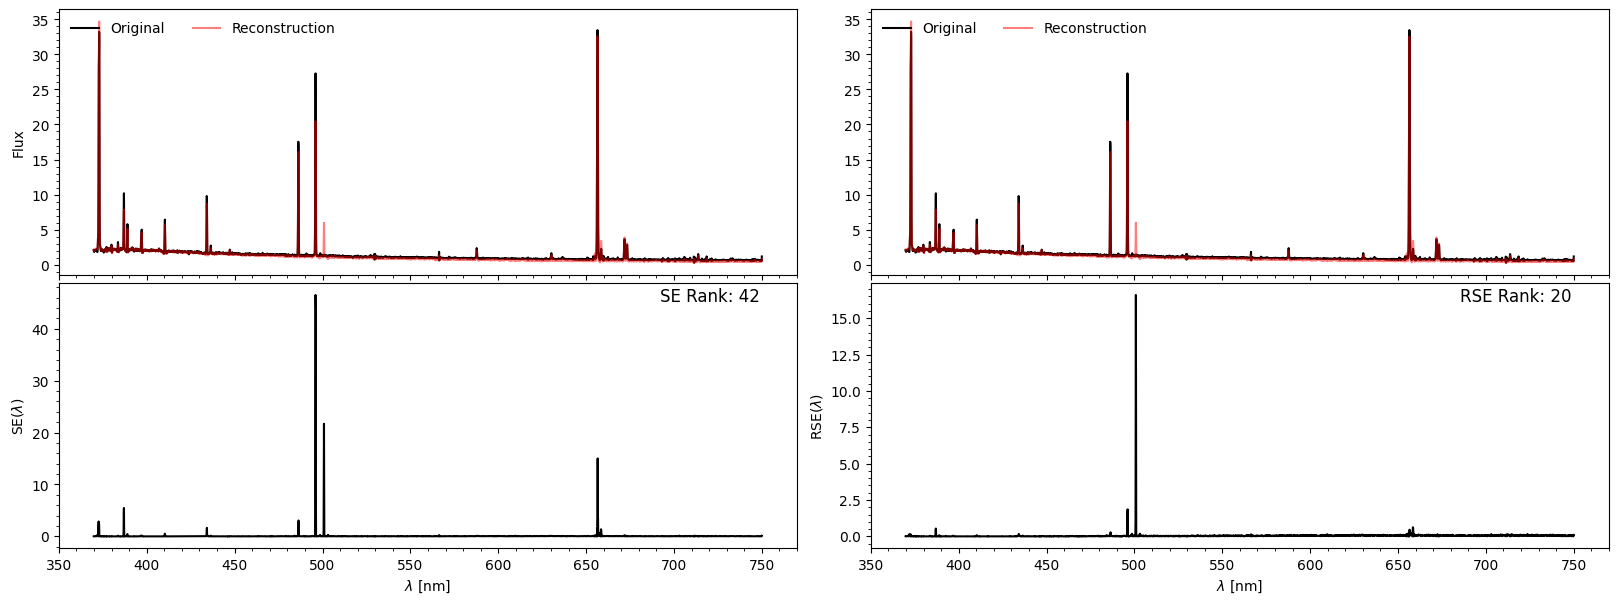

In [32]:
mask = score_rank_df.rank_mse_rel == 20
specid = score_rank_df.loc[mask].index.values[0]
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
RSEidual = rse_residual(spec, rec_spec)
squared_res = squared_residual(spec, rec_spec)
# 
rse_rank = score_rank_df.loc[specid, 'rank_mse_rel']
se_rank = score_rank_df.loc[specid, 'rank_mse']
# -------------------------------------------------------
fig, axs = rse_se_fig(
    spec, rec_spec, wave_nm,
    squared_res, RSEidual,
    se_rank, rse_rank,
    alpha=0.5
)
# adjust vertical space
plt.subplots_adjust(
    hspace=0.03, 
    wspace=0.1
)
# -------------------------------------------------------
score_rank_df.loc[specid, ['rank_mse'] + rse_rank_cols].T

rank_mse                      212.0
rank_mse_rel                   27.0
rank_mse_filter_250_rel         6.0
rank_mse_97_rel                10.0
rank_mse_filter_250_97_rel      9.0
Name: 3127826983174563840, dtype: float64

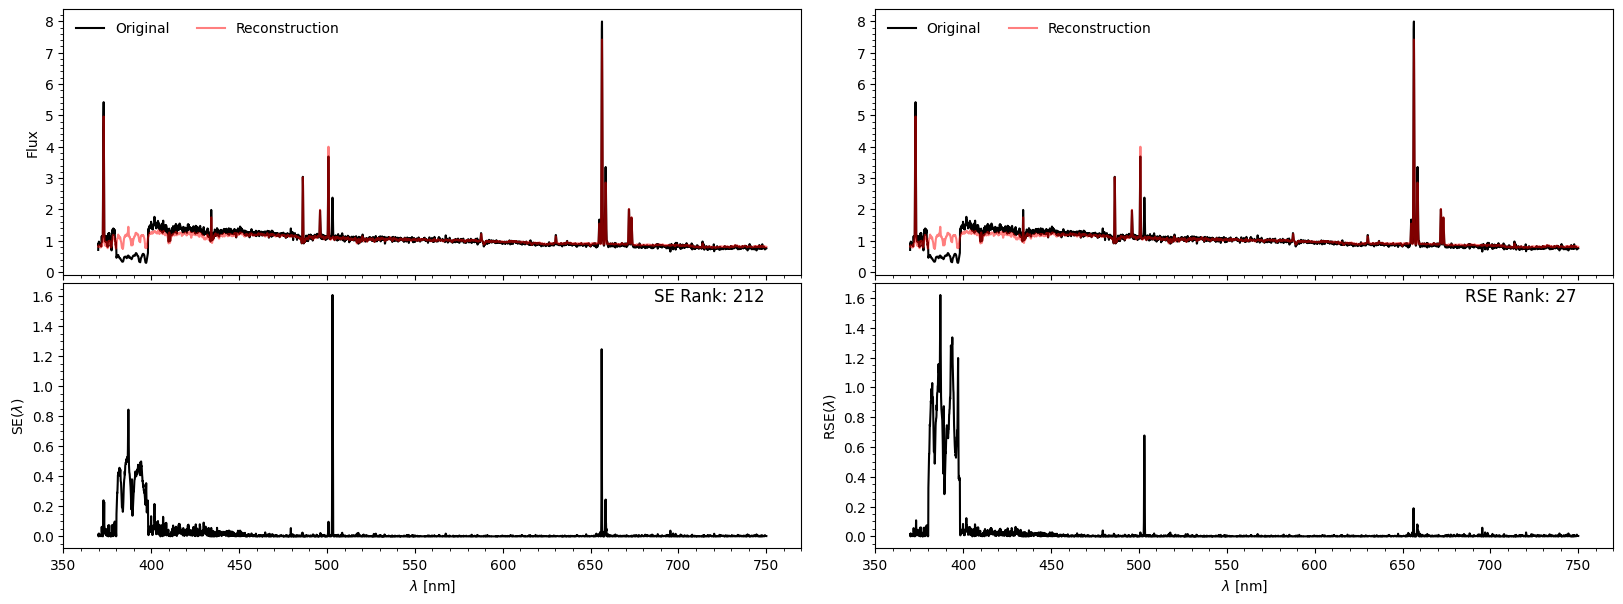

In [34]:
mask = score_rank_df.rank_mse_rel == 27
specid = score_rank_df.loc[mask].index.values[0]
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
RSEidual = rse_residual(spec, rec_spec)
squared_res = squared_residual(spec, rec_spec)
# 
rse_rank = score_rank_df.loc[specid, 'rank_mse_rel']
se_rank = score_rank_df.loc[specid, 'rank_mse']
# -------------------------------------------------------
fig, axs = rse_se_fig(
    spec, rec_spec, wave_nm,
    squared_res, RSEidual,
    se_rank, rse_rank,
    alpha=0.5
)
# adjust vertical space
plt.subplots_adjust(
    hspace=0.03, 
    wspace=0.1
)
# -------------------------------------------------------
score_rank_df.loc[specid, ['rank_mse'] + rse_rank_cols].T

rank_mse                       1223.0
rank_mse_rel                    856.0
rank_mse_filter_250_rel        2526.0
rank_mse_97_rel               11240.0
rank_mse_filter_250_97_rel    23758.0
Name: 628398147059607552, dtype: float64

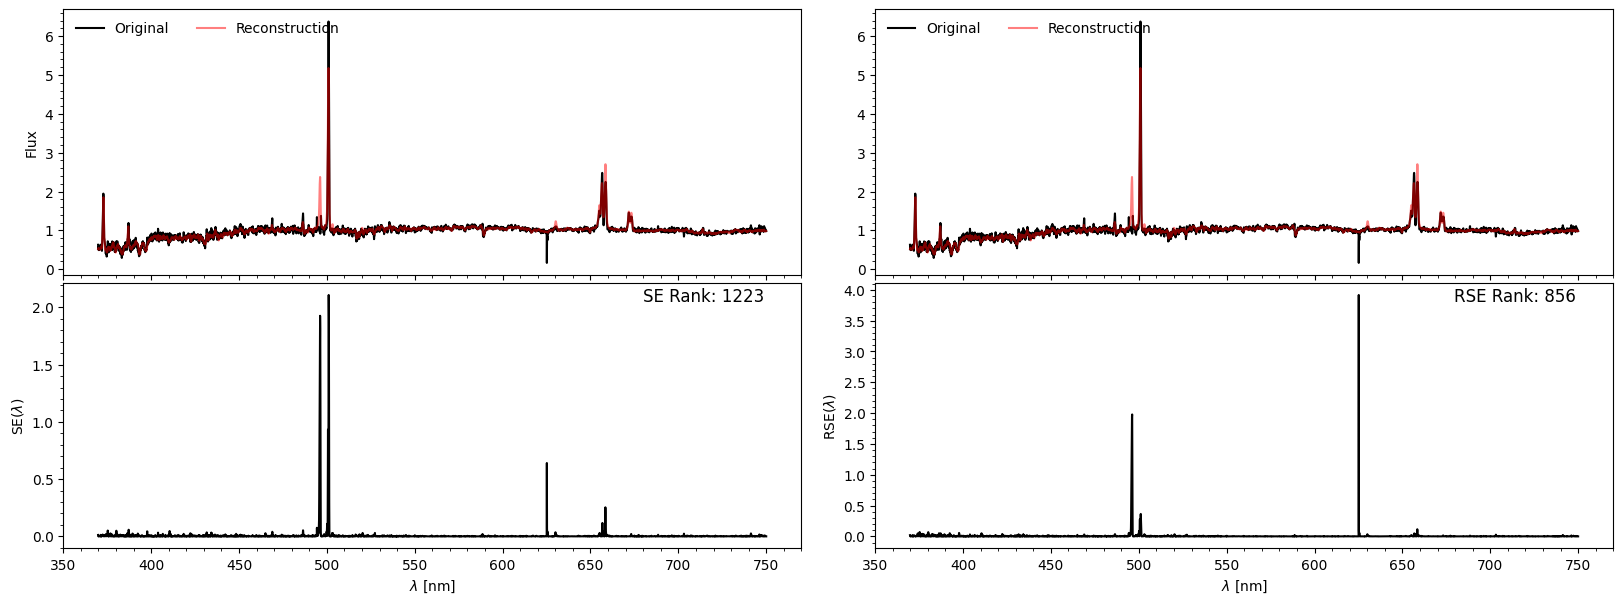

In [35]:
mask = score_rank_df.rank_mse_rel == 856
specid = score_rank_df.loc[mask].index.values[0]
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
RSEidual = rse_residual(spec, rec_spec)
squared_res = squared_residual(spec, rec_spec)
# 
rse_rank = score_rank_df.loc[specid, 'rank_mse_rel']
se_rank = score_rank_df.loc[specid, 'rank_mse']
# -------------------------------------------------------
fig, axs = rse_se_fig(
    spec, rec_spec, wave_nm,
    squared_res, RSEidual,
    se_rank, rse_rank,
    alpha=0.5
)
# adjust vertical space
plt.subplots_adjust(
    hspace=0.03, 
    wspace=0.1
)
# -------------------------------------------------------
score_rank_df.loc[specid, ['rank_mse'] + rse_rank_cols].T

# Filter RES

In [39]:
filter_rse_candidates = [
    1,
    4, # exp blue slope with flux below 1
    9, # blue slope but no flux below 1
    34, # very interesting: bumpy with a dip
    80, # similar to 34
    890, # unique to this score
]
spec_ids = []
for candidate in filter_rse_candidates:
    mask = score_rank_df.rank_mse_filter_250_rel == candidate
    specid = score_rank_df.loc[mask].index.values[0]
    spec_ids.append(specid)
score_rank_df.loc[spec_ids, rse_rank_cols]

,rank_mse_rel,rank_mse_filter_250_rel,rank_mse_97_rel,rank_mse_filter_250_97_rel
specobjid,,,,
1919783100783552512,11.0,1.0,1.0,1.0
1959139281477855232,21.0,4.0,50.0,44.0
1071977423131666432,20.0,9.0,3.0,3.0
2008626123889469440,84.0,34.0,6.0,6.0
1530151624956209152,142.0,80.0,13.0,11.0
2032375840699869184,1897.0,890.0,10328.0,12055.0


rank_mse_rel                   1896.0
rank_mse_filter_250_rel        1323.0
rank_mse_97_rel               22123.0
rank_mse_filter_250_97_rel    19899.0
Name: 319786117589133312, dtype: float64

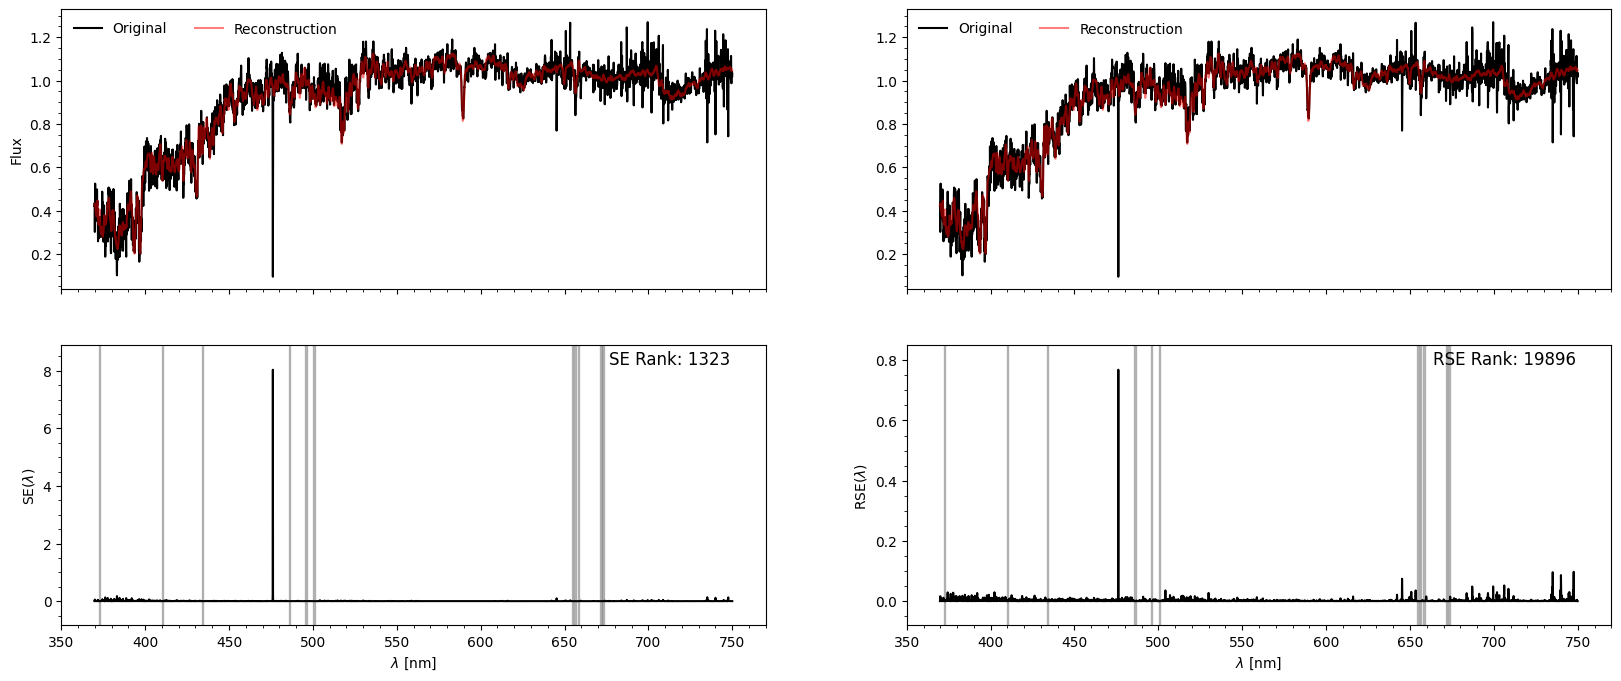

In [37]:
mask = score_rank_df.rank_mse_filter_250_rel == 1323
specid = score_rank_df.loc[mask].index.values[0]
# specid = 2032375840699869184
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
# ------------------------------------------------------
RSEidual = rse_residual(spec, rec_spec)
rseidual_vel_maked = rse_residual(spec, rec_spec)*vel_mask
# ------------------------------------------------------
squared_res = squared_residual(spec, rec_spec)
squared_res_vel_maked = squared_residual(spec, rec_spec)*vel_mask
# 
rse_rank = score_rank_df.loc[specid, 'rank_mse_filter_250_rel']
se_rank = score_rank_df.loc[specid, 'rank_mse_filter_250']
# -------------------------------------------------------
fig, axs = rse_se_fig(
    spec, rec_spec, wave_nm,
    rseidual_vel_maked, squared_res_vel_maked,
    rse_rank, se_rank,
    figsize=(20, 8),
    alpha=0.5
)
# ----------------------------------------------------
# shaded regions
axs[1, 0].fill_between(
    wave_nm, 
    0, 1,              # Fill from bottom (0) to top (1) of the axis
    where=~vel_mask,    # Only where your mask is True
    color='gray',      # Color of the shade
    alpha=0.5,         # Transparency
    transform=axs[1, 0].get_xaxis_transform(), # Key: maps y to axis fractions
    label='Masked lines'
)
axs[1, 1].fill_between(
    wave_nm, 
    0, 1,              # Fill from bottom (0) to top (1) of the axis
    where=~vel_mask,    # Only where your mask is True
    color='gray',      # Color of the shade
    alpha=0.5,         # Transparency
    transform=axs[1, 1].get_xaxis_transform(), # Key: maps y to axis fractions
    label='Masked lines'
)
# # leggends
# axs[1, 0].legend(loc='upper right', frameon=False, fontsize=10)
# axs[1, 1].legend(loc='upper right', frameon=False, fontsize=10)

# -------------------------------------------------------
# w_min, w_max = (480,510)
# w_min, w_max = (650, 680)
# axs[1, 0].set_xlim(w_min, w_max)
# axs[1, 1].set_xlim(w_min, w_max)
# -------------------------------------------------------

score_rank_df.loc[specid, rse_rank_cols].T

In [21]:
# mask = score_rank_df.rank_mse_filter_250_rel == 890
# specid = score_rank_df.loc[mask].index.values[0]
# # specid = int(specid)
# idx_spec = specobjid_to_idx(specid, idx_id_spec)
# spec = spectra[idx_spec]
# rec_spec = ae_model.reconstruct(spec)[0]
# RESidual = rse_residual(spec, rec_spec)
# # -------------------------------------------------------
# # figure
# fig, axs = fig_RSEidual(
#     wave=wave_nm,
#     wave_ticks=False,
#     wave_lims=(350, 750),
#     # wave_lims=(600, 700),
#     spec=spec, rec_spec=rec_spec,
#     flux_ticks=False, flux_lims=False,
#     residual=RESidual,
#     res_ticks=False, res_lims=False,
#     alpha = 0.5,
#     figsize=(10, 7)
# )
# # -------------------------------------------------------
# score_rank_df.loc[specid, rse_rank_cols + se_rank_cols].T

# Trim RSE

In [17]:
# mask = score_rank_df.rank_mse_97_rel == 666
# specid = score_rank_df.loc[mask].index.values[0]
# # specid = int(specid)
# idx_spec = specobjid_to_idx(specid, idx_id_spec)
# spec = spectra[idx_spec]
# rec_spec = ae_model.reconstruct(spec)[0]
# RESidual = rse_residual(spec, rec_spec)
# # -------------------------------------------------------
# # figure
# fig, axs = fig_RSEidual(
#     wave=wave_nm,
#     wave_ticks=False,
#     wave_lims=(350, 750),
#     # wave_lims=(600, 700),
#     spec=spec, rec_spec=rec_spec,
#     flux_ticks=False, flux_lims=False,
#     residual=RESidual,
#     res_ticks=False, res_lims=False,
#     alpha = 0.5,
#     figsize=(10, 7)
# )
# # -------------------------------------------------------
# score_rank_df.loc[specid, rse_rank_cols + se_rank_cols].T

In [40]:
trim_rse_candidates = [
    32,
    # red slope with flux below 1 in the blue end
    58,
    # red slope with flux below 1 in the blue end and dip in the middle
    96,
    # blue slope with small dips on red end and flux below 1 in the blue end
    # and is more anomalous in se than in rse
    195,
    # unique to trim rse
    666, # among all as well
    766,
    # unique among all
    781, # similar to 766
]
spec_ids = []
for candidate in trim_rse_candidates:
    mask = score_rank_df.rank_mse_97_rel == candidate
    specid = score_rank_df.loc[mask].index.values[0]
    spec_ids.append(specid)
score_rank_df.loc[spec_ids, rse_rank_cols]

,rank_mse_rel,rank_mse_filter_250_rel,rank_mse_97_rel,rank_mse_filter_250_97_rel
specobjid,,,,
1107962240239167488,125.0,63.0,32.0,43.0
1852219199426947072,665.0,511.0,58.0,56.0
609167407805655040,711.0,439.0,96.0,75.0
540601038567139328,488.0,413.0,195.0,218.0
1781231151415846912,2649.0,2750.0,666.0,4092.0
511298502572140544,4235.0,3565.0,766.0,2241.0
2486033238892505088,3389.0,12430.0,781.0,2184.0


rank_mse_97_rel      781.0
rank_mse_97        10654.0
Name: 2486033238892505088, dtype: float64

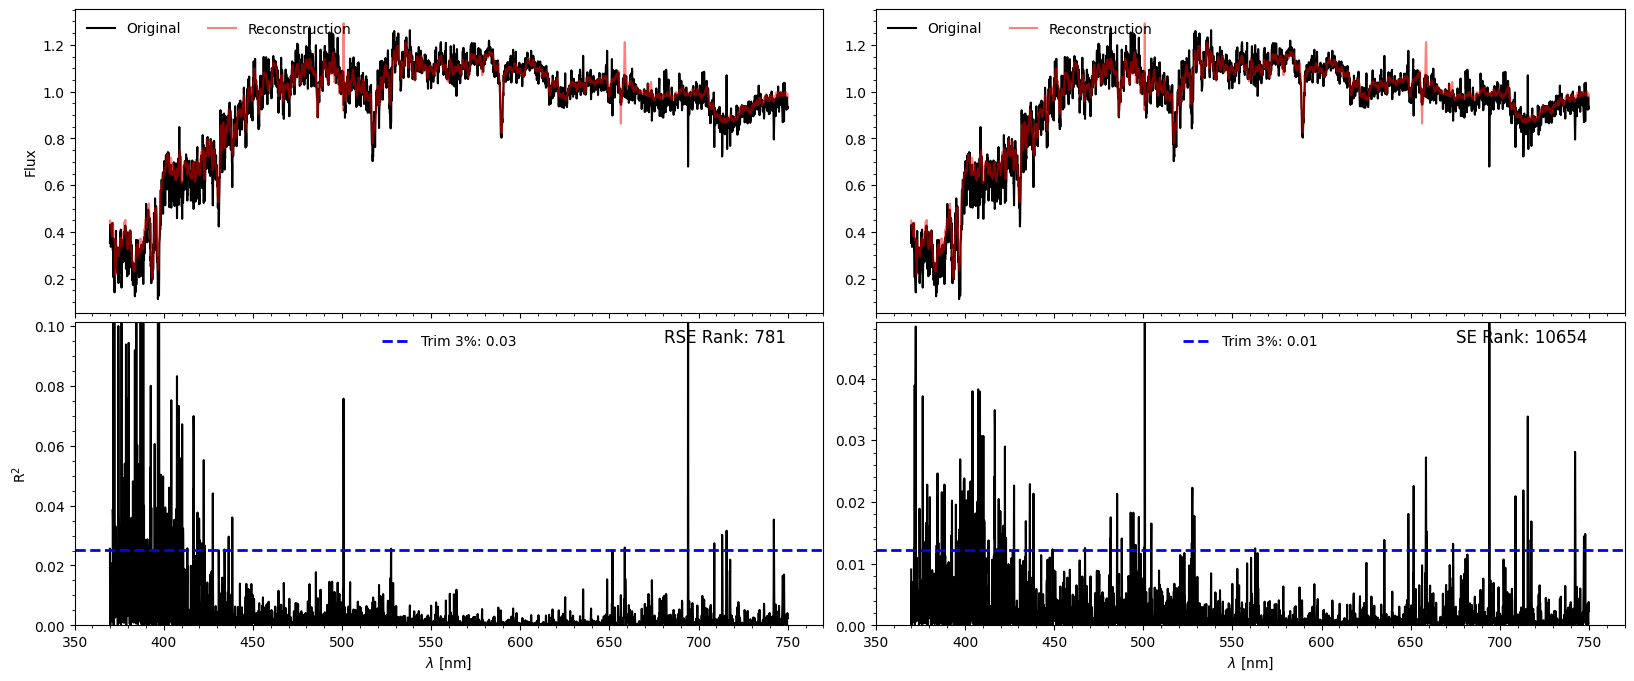

In [70]:
mask = score_rank_df.rank_mse_97_rel == 781
specid = score_rank_df.loc[mask].index.values[0]
# specid = 2032375840699869184
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
# ------------------------------------------------------
RSEidual = rse_residual(spec, rec_spec)
threshold_rse = np.nanpercentile(RSEidual, 97)
# ------------------------------------------------------
squared_res = squared_residual(spec, rec_spec)
threshold_se = np.nanpercentile(squared_res, 97)
# ------------------------------------------------------
rse_rank = score_rank_df.loc[specid, 'rank_mse_97_rel']
se_rank = score_rank_df.loc[specid, 'rank_mse_97']
# -------------------------------------------------------
fig, axs = rse_se_fig(
    spec, rec_spec, wave_nm,
    RSEidual, squared_res,
    rse_rank, se_rank,
    figsize=(20, 8),
    alpha=0.5
)
# ----------------------------------------------------
# threshold lines
axs[1, 0].axhline(
    y=threshold_rse, 
    color='blue', 
    linestyle='--', 
    linewidth=2,
    label=f'Trim 3%: {threshold_rse:.2f}'
)
axs[1, 1].axhline(
    y=threshold_se, 
    color='blue', 
    linestyle='--', 
    linewidth=2,
    label=f'Trim 3%: {threshold_se:.2f}'
)

axs[1, 0].set_ylim(0, threshold_rse*4)
axs[1, 1].set_ylim(0, threshold_se*4)

axs[1, 0].legend(loc='upper center', frameon=False)
axs[1, 1].legend(loc='upper center', frameon=False)
# -------------------------------------------------------
# w_min, w_max = (480,510)
# w_min, w_max = (650, 680)
# axs[1, 0].set_xlim(w_min, w_max)
# axs[1, 1].set_xlim(w_min, w_max)
# -------------------------------------------------------
# -------------------------------------------------------
score_rank_df.loc[specid, ['rank_mse_97_rel', 'rank_mse_97']].T

In [67]:
score_rank_df[['rank_mse_97_rel', 'rank_mse_97']].sort_values(
    by='rank_mse_97_rel', ascending=True
)

,rank_mse_97_rel,rank_mse_97
specobjid,,
1919783100783552512,1.0,1.0
2245159102839810048,2.0,2.0
1071977423131666432,3.0,4.0
2930814289679771648,4.0,3.0
969534273977608192,5.0,5.0
...,...,...
2793418210567809024,181846.0,181736.0
933518945606985728,181847.0,181429.0
2937576561018169344,181848.0,181849.0


# Check residuals for all variations

rank_mse_rel                  7.0
rank_mse_filter_250_rel       3.0
rank_mse_97_rel               4.0
rank_mse_filter_250_97_rel    4.0
Name: 2930814289679771648, dtype: float64

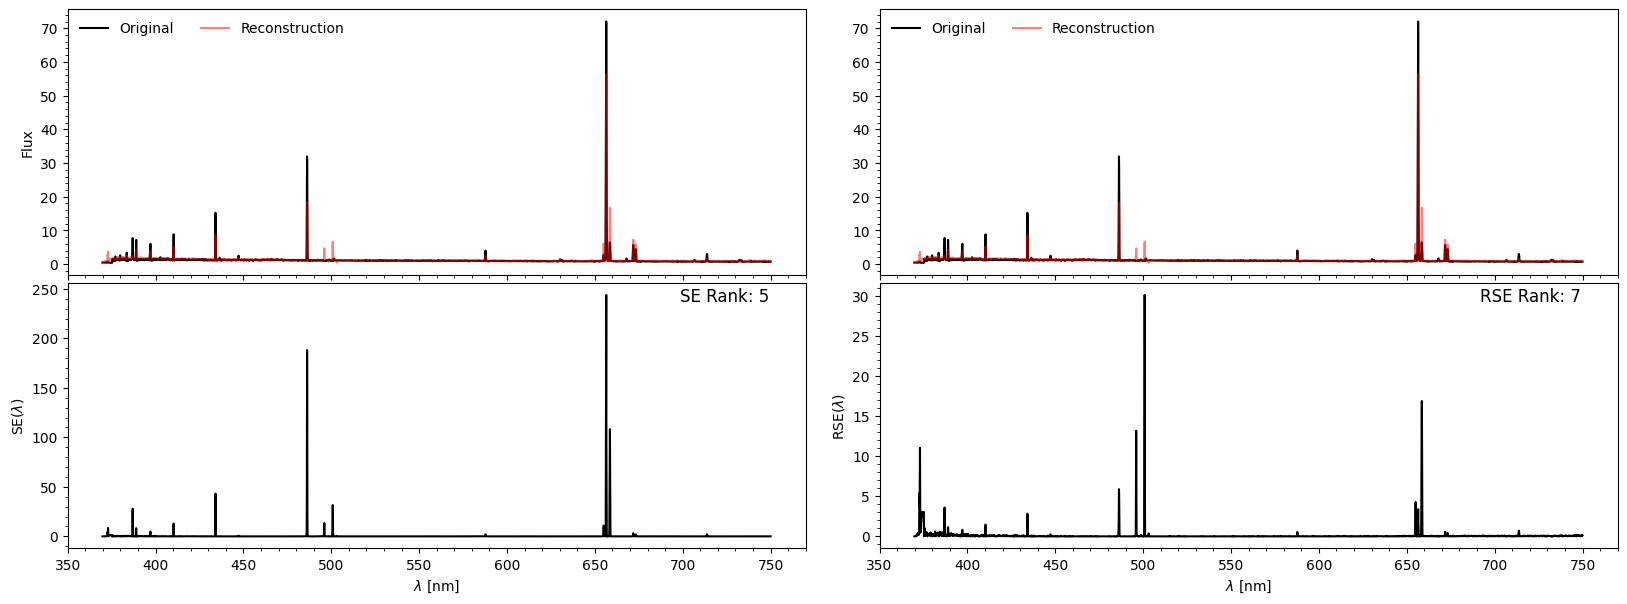

In [23]:
mask = score_rank_df.rank_mse_rel == 7
specid = score_rank_df.loc[mask].index.values[0]
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
RSEidual = rse_residual(spec, rec_spec)
squared_res = squared_residual(spec, rec_spec)
# 
rse_rank = score_rank_df.loc[specid, 'rank_mse_rel']
se_rank = score_rank_df.loc[specid, 'rank_mse']
# -------------------------------------------------------
fig, axs = rse_se_fig(
    spec, rec_spec, wave_nm,
    squared_res, RSEidual,
    se_rank, rse_rank,
    alpha=0.5
)
# adjust vertical space
plt.subplots_adjust(
    hspace=0.03, 
    wspace=0.1
)
# -------------------------------------------------------
score_rank_df.loc[specid, rse_rank_cols].T


## illustrate Filter, Trim and Filter + Trim
rank_mse_rel                   21.0
rank_mse_filter_250_rel         4.0
rank_mse_97_rel                50.0 

rank_mse                      162.0
rank_mse_rel                   21.0
rank_mse_filter_250_rel         4.0
rank_mse_97_rel                50.0
rank_mse_filter_250_97_rel     44.0
Name: 1959139281477855232, dtype: float64

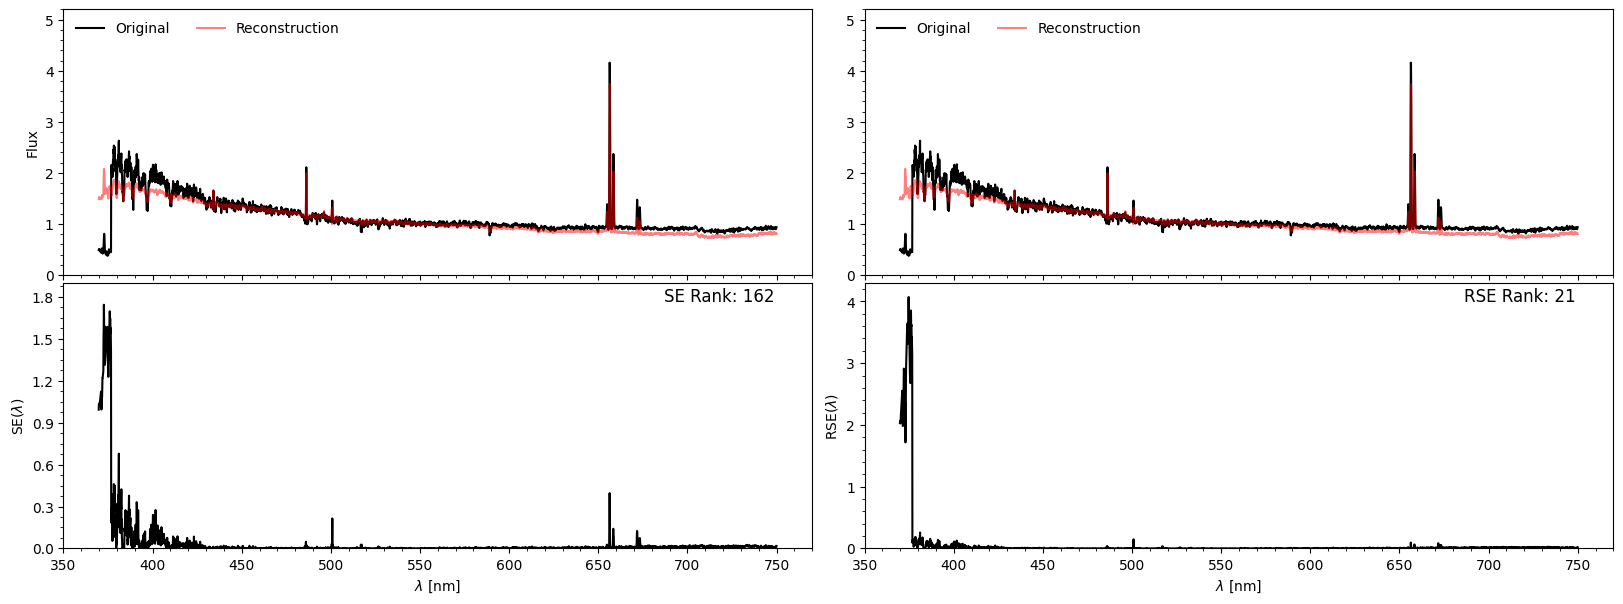

In [26]:
rse_rank = 21
mask = score_rank_df.rank_mse_rel == rse_rank
specid = score_rank_df.loc[mask].index.values[0]
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
RSEidual = rse_residual(spec, rec_spec)
squared_res = squared_residual(spec, rec_spec)
# 
rse_rank = score_rank_df.loc[specid, 'rank_mse_rel']
se_rank = score_rank_df.loc[specid, 'rank_mse']
# -------------------------------------------------------
fig, axs = rse_se_fig(
    spec, rec_spec, wave_nm,
    squared_res, RSEidual,
    se_rank, rse_rank,
    alpha=0.5
)
# --------------------------------------------------------
# Flux
flux_ticks = [0, 1, 2, 3, 4, 5]
flux_min, flux_max = (0, 5.2)
axs[0, 0].set_yticks(flux_ticks)
axs[0, 0].set_ylim(flux_min, flux_max)
axs[0, 1].set_yticks(flux_ticks)
axs[0, 1].set_ylim(flux_min, flux_max)
# --------------------------------------------------------
# Residuals
res_ticks = [0, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8]
res_min, res_max = (0, 1.9)
axs[1, 0].set_ylim(res_min, res_max)
axs[1, 0].set_yticks(res_ticks)
# 
res_ticks = [0, 1, 2, 3, 4]
res_min, res_max = (0, 4.3)
axs[1, 1].set_ylim(res_min, res_max)
axs[1, 1].set_yticks(res_ticks)
# adjust vertical space
plt.subplots_adjust(
    hspace=0.03, 
    wspace=0.07
)
score_rank_df.loc[specid, ['rank_mse'] + rse_rank_cols].T

rank_mse                       33.0
rank_mse_rel                   15.0
rank_mse_filter_250_rel       110.0
rank_mse_97_rel                27.0
rank_mse_filter_250_97_rel     49.0
Name: 2561555391200651264, dtype: float64

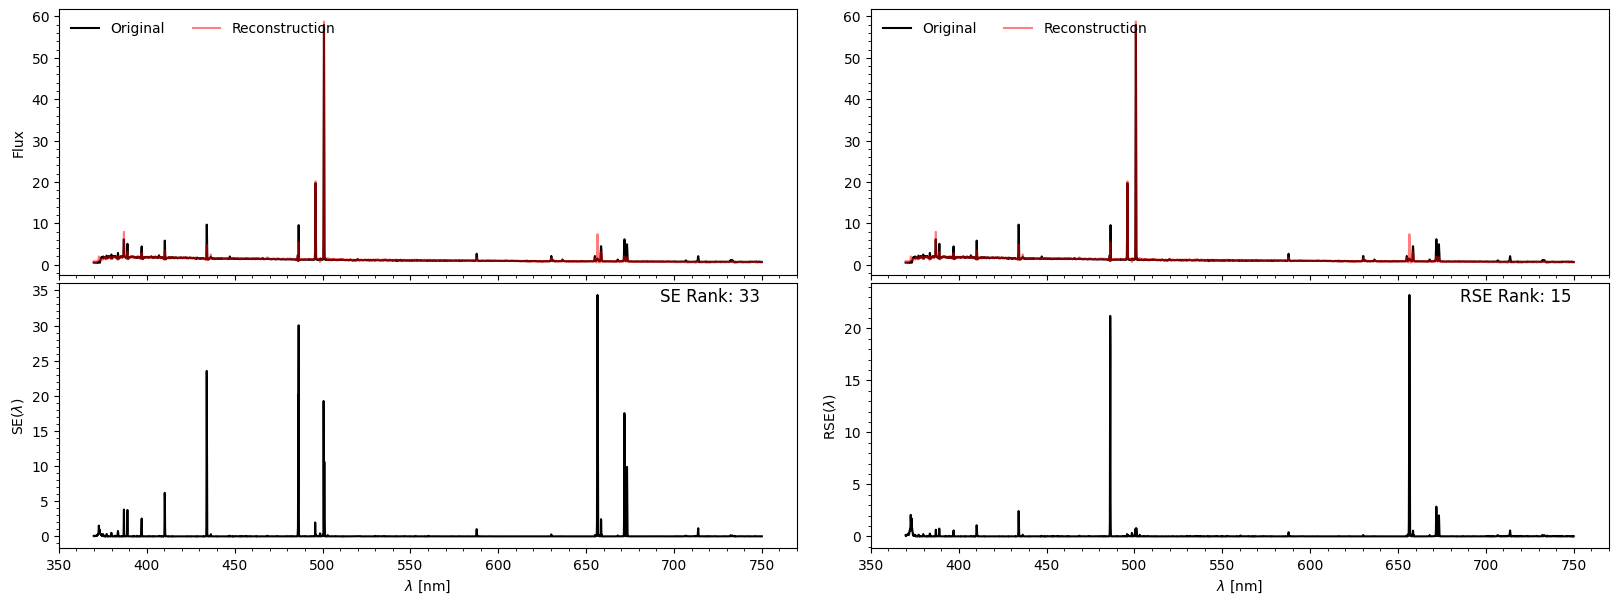

In [30]:
mask = score_rank_df.rank_mse_rel == 15
specid = score_rank_df.loc[mask].index.values[0]
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
RSEidual = rse_residual(spec, rec_spec)
squared_res = squared_residual(spec, rec_spec)
# 
rse_rank = score_rank_df.loc[specid, 'rank_mse_rel']
se_rank = score_rank_df.loc[specid, 'rank_mse']
# -------------------------------------------------------
fig, axs = rse_se_fig(
    spec, rec_spec, wave_nm,
    squared_res, RSEidual,
    se_rank, rse_rank,
    alpha=0.5
)
# adjust vertical space
plt.subplots_adjust(
    hspace=0.03, 
    wspace=0.1
)
# -------------------------------------------------------
score_rank_df.loc[specid, ['rank_mse'] + rse_rank_cols].T